# Analysing the results

This tutorial forward models one emission line, Fe XXIV 192.028, from the flare simulation of [Cheung et al. (2019)](https://doi.org/10.1038/s41550-018-0629-3) through EUVST-SW, and shows the intensity map it would record. It goes through every step: downloading the simulation, writing the atmosphere file, synthesising the line, simulating the instrument, and loading the results.

## Before you start

| Resource | Needed |
| --- | --- |
| Download | 1.2 GB of simulation data |
| Disk | about 25 GB, mostly for the synthesis file |
| Memory | about 130 GB |
| Wall clock | about 20 minutes on 256 cores |

Contribution functions come from CHIANTI through [fiasco](https://fiasco.readthedocs.io/), which needs a local copy of the CHIANTI database.

In [1]:
from urllib.request import urlretrieve

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.colors import LogNorm

from euvst_response import (
    Atmosphere,
    create_sunpy_maps_from_combo,
    edges_from_centres,
    get_results_for_combination,
    load_instrument_response_results,
    summary_table,
    write_atmosphere,
)

## 1. Download the simulation

The [Hinode SDC Europe](https://sdc.uio.no/search/simulations) hosts snapshots of the simulation, run `ar098192`, as FITS files with one variable per file. Snapshot 300000 is during the flare. The synthesis needs the temperature, the density, and the velocity along the line of sight, which for a view from above is the vertical velocity.

In [2]:
SNAPSHOT = 300000
URL = "https://sdc.uio.no/vol/simulations/ar098192/atmos"

for variable in ("lgtg", "lgr", "uz"):
    name = f"MURaM_ar098192_{variable}_{SNAPSHOT}.fits"
    urlretrieve(f"{URL}/{name}", name)
    print(name)

MURaM_ar098192_lgtg_300000.fits
MURaM_ar098192_lgr_300000.fits
MURaM_ar098192_uz_300000.fits


## 2. Write the atmosphere file

This is the MURaM example on the [synthesis page](../synthesis/#worked-example-a-muram-flare). The values are in SI units, variables whose names start with `lg` are base-10 logarithms, and the heights of the cell centres are in the first FITS extension.

In [3]:
def variable(name):
    with fits.open(f"MURaM_ar098192_{name}_{SNAPSHOT}.fits") as hdul:
        return hdul[0].data, hdul[0].header, hdul[1].data  # cube (nz, ny, nx), header, z centres in Mm

lgtg, header, z = variable("lgtg")
lgr, _, _ = variable("lgr")
uz, _, _ = variable("uz")

nz, ny, nx = lgtg.shape
x = (header["CRVAL1"] + (np.arange(nx) + 1 - header["CRPIX1"]) * header["CDELT1"]) * u.Mm
y = (header["CRVAL2"] + (np.arange(ny) + 1 - header["CRPIX2"]) * header["CDELT2"]) * u.Mm

atmosphere = Atmosphere(
    temperature=10.0 ** lgtg.astype(np.float64) * u.K,
    mass_density=10.0 ** lgr.astype(np.float64) * u.kg / u.m**3,
    velocity_z=uz * u.m / u.s,
    x_edges=edges_from_centres(x), y_edges=edges_from_centres(y),
    z_edges=edges_from_centres(z * u.Mm),
    time=header["ELAPSED"] * u.s,
    source=f"MURaM ar098192 snapshot {SNAPSHOT}, Hinode SDC Europe",
)
write_atmosphere(atmosphere, f"muram_{SNAPSHOT}.h5")
print(atmosphere.describe())

  Shape (nz, ny, nx): (768, 256, 512)
  x: -49.152 Mm to 49.152 Mm, cells of 0.1920 Mm
  y: -24.576 Mm to 24.576 Mm, cells of 0.1920 Mm
  z: -7.500 Mm to 41.652 Mm, cells from 0.0640 Mm to 0.0640 Mm
  Density: mass_density
  Velocities: z
  Time: 28451.000 s
  Source: MURaM ar098192 snapshot 300000, Hinode SDC Europe


## 3. Synthesise the line

The box runs from 7.5 Mm below the surface, so `--crop-z` keeps the part above it. The flows in the flare are faster than the default velocity grid of +/-300 km/s covers, so it is widened to +/-1000 km/s.

In [4]:
!synthesise-spectra --atmosphere muram_300000.h5 \
  --lines Fe24_192.0280 \
  --crop-z "0 Mm" "42 Mm" \
  --vel-lim "1000 km/s" --vel-res "10 km/s" \
  --output-dir ./run/input --output-name muram_flare_fe24.h5

STATIC MODE - Synthesis from an atmosphere file
  Atmosphere: muram_300000.h5
  Integration axis: z
  Velocity grid: +/-1000.0 km / s at 10.0 km / s resolution
  Precision: <class 'numpy.float64'>
  Lines: ['Fe24_192.0280']
  Abundance: sun_coronal_2021_chianti
  Cropping: X=None, Y=None, Z=['0 Mm', '42 Mm']

Reading the atmosphere (17.37/540.81 GB)
  Shape (nz, ny, nx): (651, 256, 512)
  x: -49.152 Mm to 49.152 Mm, cells of 0.1920 Mm
  y: -24.576 Mm to 24.576 Mm, cells of 0.1920 Mm
  z: -0.012 Mm to 41.652 Mm, cells from 0.0640 Mm to 0.0640 Mm
  Density: mass_density
  Velocities: z
  Time: 28451.000 s
  Source: MURaM ar098192 snapshot 300000, Hinode SDC Europe
Electron density from the mass density with 1.1579 u per electron (fully ionised plasma with sun_coronal_2021_chianti abundances)
Computing contribution functions via fiasco (22.88/540.81 GB)
Computing G(T,N): 100%|█████████████████████████| 1/1 [09:01<00:00, 541.15s/ion]
  Fe24_192.0280: requested 192.0280 Angstrom, matched 19

## 4. Simulate the instrument

The configuration observes the synthesis file with EUVST-SW, with the 0.4 arcsec slit and 3 s exposures. `n_iter: 10` repeats the observation ten times with independent noise, and `fit_signals: dn` fits the spectra as the detector records them. See [the configuration file reference](../instrument-response/#configuration-file) for the other options.

In [5]:
%%writefile run/input/muram_flare_fe24.yaml
instrument: SWC
synthesis_file: ./run/input/muram_flare_fe24.h5
reference_line: Fe24_192.0280

n_iter: 10
ncpu: -1
fit_signals: dn

simulation:
  slit_width: 0.4 arcsec
  expos: 3 s
  psf: True

Overwriting run/input/muram_flare_fe24.yaml


In [6]:
!eclipse --config run/input/muram_flare_fe24.yaml


  ______ _____ _      _____ _____   _____ ______
 |  ____/ ____| |    |_   _|  __ \ / ____|  ____|
 | |__ | |    | |      | | | |__) | (___ | |__
 |  __|| |    | |      | | |  ___/ \___ \|  __|
 | |___| |____| |____ _| |_| |     ____) | |____
 |______\_____|______|_____|_|    |_____/|______|

ECLIPSE: Emission Calculation and Line Prediction for SOLAR-C EUVST

Contact: James McKevitt (jm2@mssl.ucl.ac.uk). See LICENSE for usage terms.

Running instrument response simulation with config: run/input/muram_flare_fe24.yaml
------------------------------------------------------------
Fitting only 'dn' signal (skipping 'photon')
.../euvst_response/main.py:647: UserWarning: The SWC PSF is the modelled PSF including simulations and some microroughness measurements. Final PSF will be measured before launch.
  warnings.warn(

Running 1 parameter combination(s).

Loading the synthesis...
Using 'Fe24_192.0280' as reference line for wavelength grid and metadata...
  Lines in its window: Fe24_192.028

## 5. Load the results

The results file holds every combination of the parameters in the configuration. `summary_table` lists them, with the parameter names that `get_results_for_combination` takes to pick one. This run has only one.

In [7]:
results = load_instrument_response_results("run/result/muram_flare_fe24.pkl")
summary_table(results)

Software version : 0.11.0
Git commit       : 15049636805e3582da4d8b59045e308d409e9f97

detector.ccd_temperature | detector.dark_current    | detector.filter_distance | detector.full_well       | detector.gain_e_per_dn   | detector.material        | detector.max_dn          | detector.pix_size        | detector.plate_scale_angle | detector.qe_euv          | detector.qe_vis          | detector.read_noise_rms  | detector.wvl_res         | filter.al_thickness      | filter.c_thickness       | filter.mesh_throughput   | filter.oxide_thickness   | filter.table_thickness   | offchip_bin_slit         | simulation.enable_pinholes | simulation.expos         | simulation.instrument    | simulation.n_iter        | simulation.ncpu          | simulation.noise         | simulation.pinhole_positions_spectral | simulation.psf           | simulation.psf_boundary  | simulation.slit_width    | simulation.spectral_psf  | simulation.vis_sl        | telescope.D_ap           | telescope.microroughness_sigma |

In [8]:
combination = get_results_for_combination(results, **{
    "simulation.slit_width": 0.4 * u.arcsec,
    "simulation.expos": 3 * u.s,
})

# A simulation has no date of its own, so the maps are given one.
maps = create_sunpy_maps_from_combo(combination, data_type="dn", date_obs="2024-03-20T00:00:00")
print(sorted(maps))

['failed_fits', 'intensity_from_fit', 'intensity_mean', 'intensity_std', 'line_width_from_fit', 'line_width_mean', 'line_width_std', 'total_dn', 'total_photons', 'velocity_err', 'velocity_from_fit', 'velocity_mean', 'velocity_std', 'velocity_true']


## 6. The intensity map

`total_dn` is the signal in the Fe XXIV window, summed over wavelength, from the first of the ten observations. It is an ordinary SunPy map.

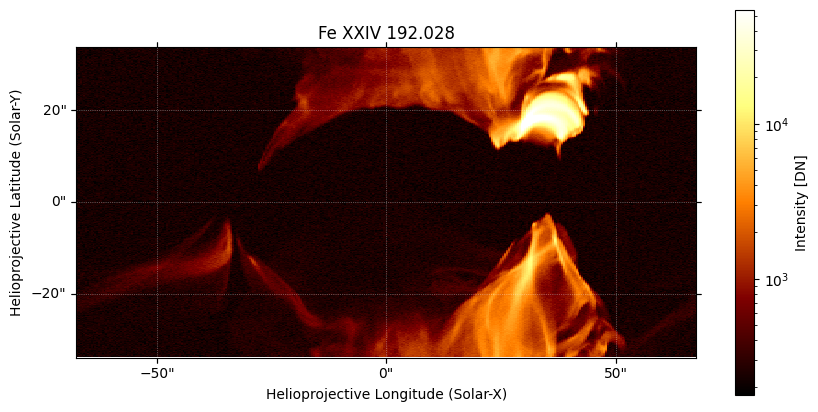

In [9]:
intensity = maps["total_dn"]
low, high = np.nanpercentile(intensity.data, [1, 99.9])

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection=intensity)
image = intensity.plot(axes=ax, title="Fe XXIV 192.028", norm=LogNorm(low, high))
fig.colorbar(image, ax=ax, label="Intensity [DN]")
plt.show()